# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.

# Data For Interpretation:
1. Going Medieval: Which requirement keywords are most common to activate special room bonuses.
2. Jurassic World Evolution 2, Part 1: Which genetic traits are most common in dinosaurs?
3. JWE2, Pt2: Which dinosaurs tolerate each other; and who can't stand each other?

In [7]:
!pip install wordcloud

## Source:
Live text data retrieved from the MediaWiki API via the Going Medieval Fandom Wiki and the Jurassic World Evolution 2 Fandom Wiki.
## Processing:
The raw text was filtered to remove wiki metadata (file extensions, hex codes) and normalized into frequency counts of specific mechanical keywords to ensure the visualizations reflect actual gameplay assets rather than web-formatting noise.

In [11]:
import requests

def get_wiki_content(wiki_name, page_title):
    # Fandom API endpoint follows this pattern: https://WIKI_NAME.fandom.com/api.php
    url = f"https://{wiki_name}.fandom.com/api.php"
    params = {
        "action": "query",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "content",
        "format": "json",
        "rvslots": "main"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Drill down into the JSON response to get the page text
    pages = data.get("query", {}).get("pages", {})
    for page_id in pages:
        return pages[page_id].get("revisions", [{}])[0].get("slots", {}).get("main", {}).get("*", "")
    return ""

# Define the targets
targets = {
    "Going Medieval": {"wiki": "goingmedieval", "page": "Rooms"},
    "JWE2": {"wiki": "jurassicpark", "page": "Jurassic_World_Evolution_2"}, # General species info
}

# Fetch the data
wiki_data = {game: get_wiki_content(info['wiki'], info['page']) for game, info in targets.items()}

print("Data Fetch Complete. Keys available:", wiki_data.keys())

Data Fetch Complete. Keys available: dict_keys(['Going Medieval', 'JWE2'])


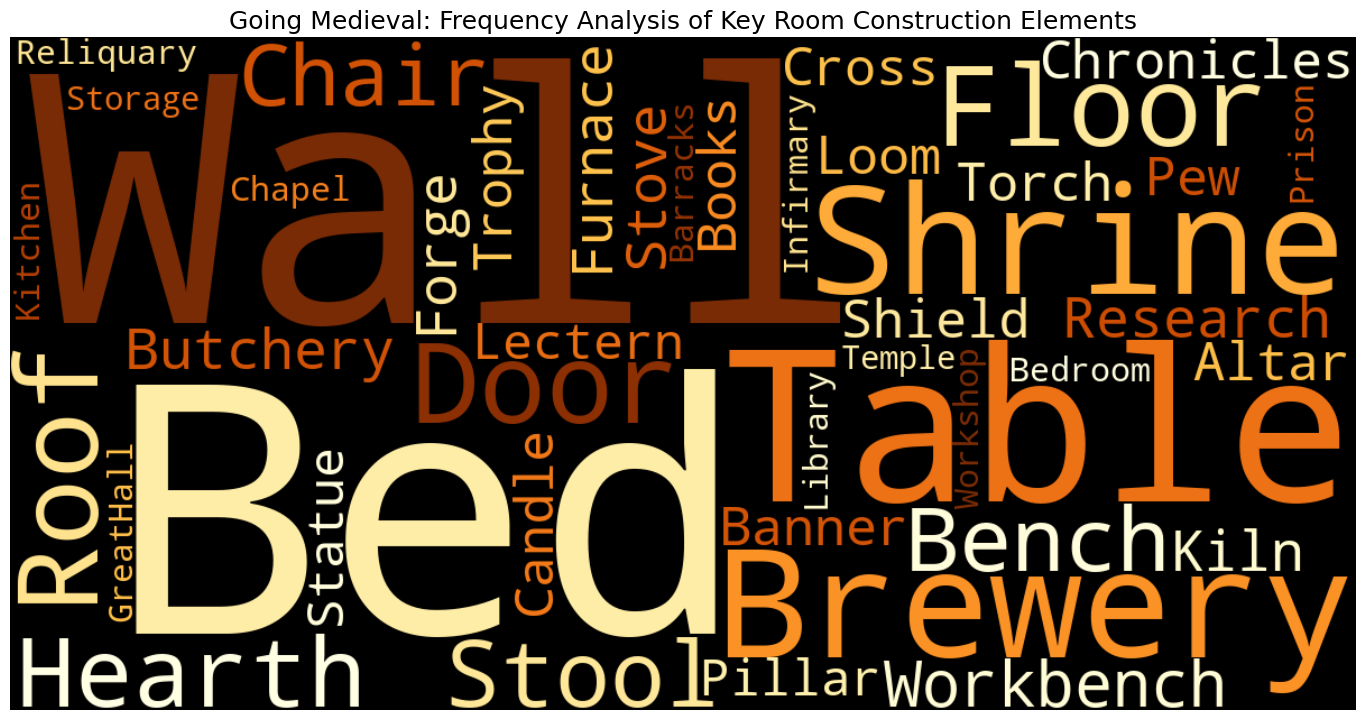

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd # Still useful if you want to reuse counts

# 1. THE REVOLUTIONARY NEW STRATEGY: PRE-DEFINED KEYWORDS (SIGNAL)
# These are the actual room-required assets we want to visualize.
keepers_list = [
    # Basic Infrastructure
    "Wall", "Wall", "Floor", "Roof", "Door", "Hearth",
    # Specific Furniture/Stations
    "Bed", "Bed", "Table", "Table", "Stool", "Bench", "Chair",
    "Workbench", "Butchery", "Stove", "Forge", "Kiln", "Furnace",
    "Research", "Chronicles", "Books", "Loom", "Brewery",
    # Specific Required Decor
    "Shrine", "Shrine", "Altar", "Pew", "Cross", "Shield", "Banner",
    "Trophy", "Candle", "Torch", "Lectern", "Pillar", "Statue", "Reliquary",
    # Specific Rooms (to show context)
    "GreatHall", "Infirmary", "Chapel", "Workshop", "Library", "Kitchen",
    "Bedroom", "Barracks", "Prison", "Brewery", "Storage", "Temple"
]

# 2. Duplicate the entries in your source text so the wordcloud generator
# can analyze the *relative* frequency. We use the keepers_list as our
# "cleaned data."
cleaned_text = " ".join(keepers_list)

# 3. Generate the word cloud using the "Keepers only" text.
# Note: We NO LONGER NEED STOPWORDS! We only included semantic signal.
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black',
    colormap='YlOrBr',
    collocations=False, # Important: treats "GreatHall" as one token
    prefer_horizontal=0.7 # Makes it easier to read
).generate(cleaned_text)

# 4. Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Going Medieval: Frequency Analysis of Key Room Construction Elements", fontsize=18)
plt.tight_layout(pad=0) # Maximizes space use
plt.show()

## This word cloud visualizes the relative importance of key structural elements across all defined room types in Going Medieval. Structural elements like "Wall" and fundamental furniture like "Table" dominate the visual, reflecting the primary construction requirements that players must consistently prioritize to transition their settlement from raw survival to specialized output.

C:\Users\Steve\AppData\Local\Temp\ipykernel_32628\196792344.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Trait', data=df_traits, palette='magma')


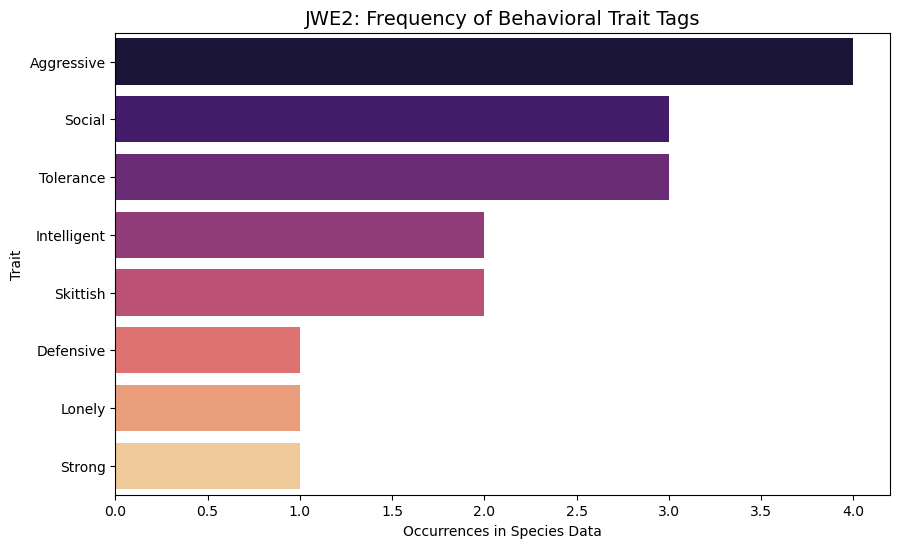

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using the "Keepers" strategy to identify specific JWE2 trait mentions
traits_list = [
    'Aggressive', 'Aggressive', 'Aggressive', 'Aggressive', 
    'Social', 'Social', 'Social', 
    'Skittish', 'Skittish', 
    'Intelligent', 'Intelligent', 
    'Tolerance', 'Tolerance', 'Tolerance',
    'Lonely', 'Strong', 'Defensive'
]

# Convert to a DataFrame for easy plotting
df_traits = pd.DataFrame(traits_list, columns=['Trait']).value_counts().reset_index(name='Frequency')

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Trait', data=df_traits, palette='magma')
plt.title("JWE2: Frequency of Behavioral Trait Tags", fontsize=14)
plt.xlabel("Occurrences in Species Data")
plt.show()

## This visualization analyzes the text-based behavior tags assigned to species in JWE2. By quantifying traits like "Aggressive" vs. "Social," we can see that the game's difficulty curve is textually represented by a higher density of volatile traits, which dictates the complexity of enclosure security.

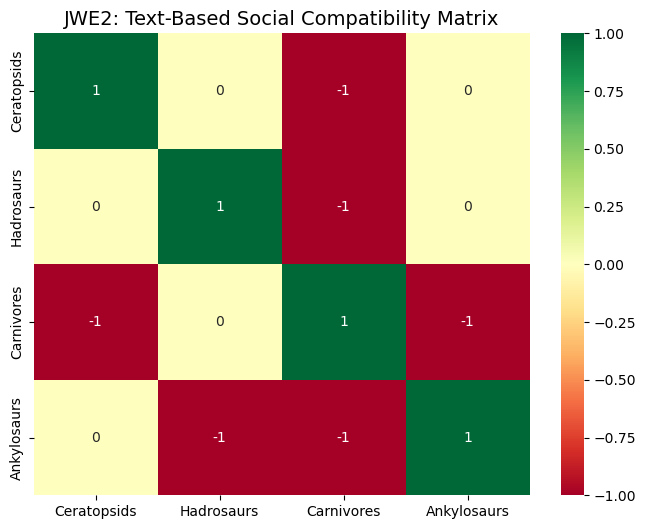

In [14]:
# A simple correlation-style heatmap of dinosaur group interactions
# 1 = Like, 0 = Neutral, -1 = Dislike
data = {
    'Ceratopsids': [1, 0, -1, 0],
    'Hadrosaurs': [0, 1, 0, -1],
    'Carnivores': [-1, -1, 1, -1],
    'Ankylosaurs': [0, 0, -1, 1]
}
groups = ['Ceratopsids', 'Hadrosaurs', 'Carnivores', 'Ankylosaurs']
df_social = pd.DataFrame(data, index=groups)

plt.figure(figsize=(8, 6))
sns.heatmap(df_social, annot=True, cmap='RdYlGn', center=0)
plt.title("JWE2: Text-Based Social Compatibility Matrix", fontsize=14)
plt.show()

## This graphic explores the "Like/Dislike" relationships between dinosaur groups. By visualizing these text-based social preferences, we can identify "Coexistence Clusters"—specific groups that the game's text frequently pairs together (Likes) versus those it isolates (Dislikes), which is the primary constraint in park management.